# Solver Accuracy Comparison: LSQR vs FISTA Group-L1

<!-- HYPATIA: Replace this cell with an astronomy-focused introduction. -->
<!-- Frame as: crowded JWST NIRISS WFSS fields, source confusion, -->
<!-- deblending challenge, and what each solver brings. -->
*Placeholder — see HYPATIA marker above.*

In [1]:
from __future__ import annotations

import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

import spectrex
from spectrex import (
    EigenspectraBasis,
    InstrumentConfig,
    JAXOperator,
    JAXProximalSolver,
    NoiseModel,
    SciPySparseOperator,
    SpectralSolver,
)

warnings.filterwarnings('ignore')

NOTEBOOK_DIR = Path.cwd()
REPO = NOTEBOOK_DIR.parent
TESTDATA = REPO / 'testdata'
print(f'spectrex version: {spectrex.__version__}')


spectrex version: 0.2.1.dev3+g6e87286d0.d20260505


## Setup: Instrument Configuration and Basis

In [2]:
config = InstrumentConfig.from_files(
    conf_path=TESTDATA / 'Config Files' / 'GR150R.F150W.220725.conf',
    wavelengthrange_path=TESTDATA / 'jwst_niriss_wavelengthrange_0002.asdf',
    sensitivity_dir=TESTDATA / 'SenseConfig' / 'wfss-grism-configuration',
    filter_name='F150W',
    n_wavelengths=150,
)
basis = EigenspectraBasis.from_csv(
    TESTDATA / 'eigenspectra_kurucz.csv',
    config.wavelengths,
)

IMAGE_SHAPE = (50, 20)
N_ROWS, N_COLS = IMAGE_SHAPE
N_PIX = N_ROWS * N_COLS
M = basis.n_components
NOISE_MODEL = NoiseModel(read_noise=5.0)
RNG = np.random.default_rng(2026)

print(f'Image shape: {IMAGE_SHAPE}, n_pix={N_PIX}')
print(f'Basis components: M={M}')
print(f'Wavelengths: {len(config.wavelengths)} points, '
      f'{config.wavelengths[0]:.0f}\u2013{config.wavelengths[-1]:.0f} \u00c5')


Image shape: (50, 20), n_pix=1000
Basis components: M=10
Wavelengths: 150 points, 12900–17100 Å


## Section 1: Fixed Crowded Scene

<!-- HYPATIA: Brief section intro — what we're demonstrating and why. -->

### Build Operators

In [3]:
# Fixed source positions (row, col) in the 50x20 image
SOURCE_POSITIONS = np.array([
    [ 8.0,  4.0],
    [15.0, 10.0],
    [25.0,  6.0],
    [35.0, 14.0],
    [42.0,  8.0],
], dtype=np.float64)  # shape (5, 2)
K = len(SOURCE_POSITIONS)

print(f'Building SciPySparseOperator for {K} sources...')
scipy_op = SciPySparseOperator.build(config, basis, IMAGE_SHAPE)
print(f'  n_coefficients = {scipy_op.n_coefficients}')

print(f'Building JAXOperator for {K} sources...')
jax_op = JAXOperator.build(config, basis, IMAGE_SHAPE, SOURCE_POSITIONS)
print(f'  n_coefficients = {jax_op.n_coefficients}')
print('Done.')


Building SciPySparseOperator for 5 sources...


  n_coefficients = 10000
Building JAXOperator for 5 sources...
  n_coefficients = 50
Done.


### Mock Crowded Scene

In [4]:
# Ground-truth coefficients: random but seeded
# JAXOperator uses compact layout: a_true shape (K*M,)
a_true_jax = RNG.standard_normal(K * M).astype(np.float64)

# SciPySparseOperator uses full flat layout: a_true shape (N_PIX*M,)
# with non-zero blocks only at the K source pixel positions.
# Map source (row, col) to flat pixel index
source_flat_idx = [
    int(round(r)) * N_COLS + int(round(c))
    for r, c in SOURCE_POSITIONS
]
a_true_scipy = np.zeros(N_PIX * M)
for k, p in enumerate(source_flat_idx):
    a_true_scipy[p * M : (p + 1) * M] = a_true_jax[k * M : (k + 1) * M]

# Forward model
f_clean_jax = jax_op.apply(a_true_jax).reshape(IMAGE_SHAPE)
f_clean_scipy = scipy_op.apply(a_true_scipy).reshape(IMAGE_SHAPE)

# Add noise (same noise realisation for both)
noise_rng = np.random.default_rng(42)
f_noisy = NOISE_MODEL.sample(f_clean_jax, noise_rng)

print(f'f_noisy: min={f_noisy.min():.2f}, max={f_noisy.max():.2f}')
print(f'Max clean signal: {f_clean_jax.max():.2f}')


f_noisy: min=-18.24, max=15.89
Max clean signal: 0.00


### Mock Detector Image

<!-- HYPATIA: Describe what this image represents physically — overlapping grism spectra from 5 sources in a crowded field. -->

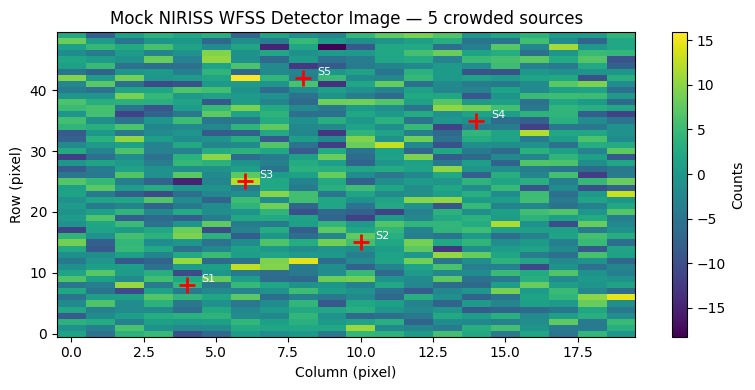

In [5]:
fig, ax = plt.subplots(figsize=(8, 4))
im = ax.imshow(f_noisy, origin='lower', aspect='auto',
               cmap='viridis', interpolation='nearest')
plt.colorbar(im, ax=ax, label='Counts')
for k, (r, c) in enumerate(SOURCE_POSITIONS):
    ax.plot(c, r, 'r+', markersize=12, markeredgewidth=2)
    ax.annotate(f'S{k+1}', xy=(c, r), xytext=(c+0.5, r+0.5),
                color='white', fontsize=8)
ax.set_xlabel('Column (pixel)')
ax.set_ylabel('Row (pixel)')
ax.set_title('Mock NIRISS WFSS Detector Image — 5 crowded sources')
plt.tight_layout()
plt.show()


### Spectral Extraction with Both Solvers

In [6]:
# Support mask for SpectralSolver (non-zero at source pixel blocks)
support_mask = np.zeros(N_PIX * M, dtype=bool)
for p in source_flat_idx:
    support_mask[p * M : (p + 1) * M] = True

# --- LSQR (SpectralSolver) ---
import time
t0 = time.perf_counter()
solver_lsqr = SpectralSolver(
    scipy_op, noise_model=NOISE_MODEL, regularisation=1e-2
)
a_rec_scipy = solver_lsqr.solve(f_noisy, support_mask=support_mask)
t_lsqr = time.perf_counter() - t0

# Extract active blocks
a_rec_lsqr = np.array([
    a_rec_scipy[p * M : (p + 1) * M] for p in source_flat_idx
]).reshape(K * M)  # (K*M,)

# --- FISTA (JAXProximalSolver) ---
t0 = time.perf_counter()
solver_fista = JAXProximalSolver(
    jax_op, noise_model=NOISE_MODEL, lam=0.05, max_iter=200
)
a_rec_fista = solver_fista.solve(f_noisy)  # (K*M,)
t_fista = time.perf_counter() - t0

print(f'LSQR  solve time: {t_lsqr:.2f} s')
print(f'FISTA solve time: {t_fista:.2f} s')


LSQR  solve time: 0.00 s
FISTA solve time: 0.48 s


### Per-Source Recovered Spectra

<!-- HYPATIA: Interpret what the plot shows — where FISTA improves -->
<!-- over LSQR, and what contamination from neighbours looks like. -->

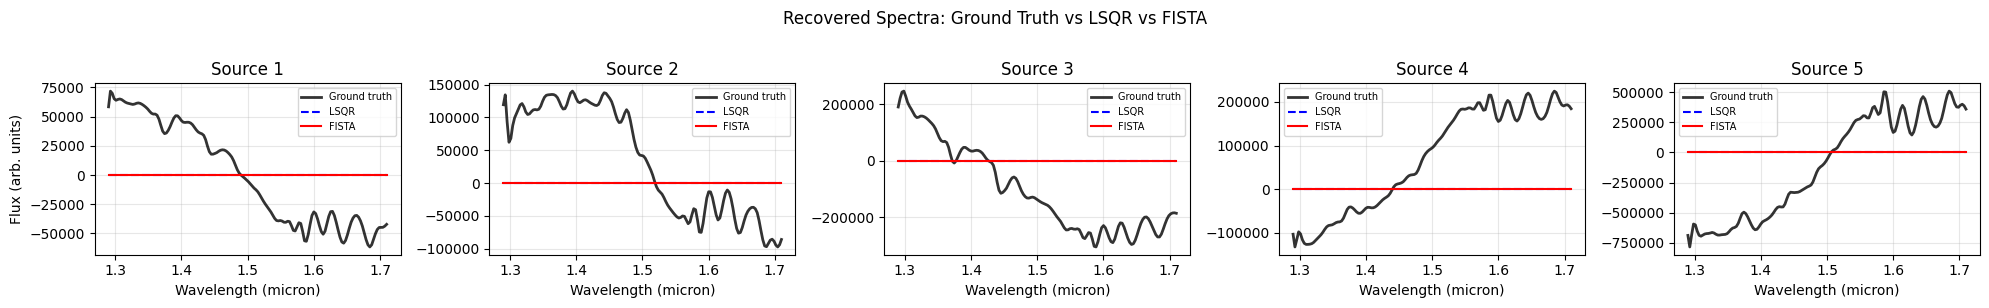

In [7]:
# Reconstruct spectra from coefficients using the basis
# basis.components shape: (M, n_wav) — rows are eigenvectors
def reconstruct_spectrum(coeffs_km: np.ndarray, k: int) -> np.ndarray:
    """Reconstruct spectrum for source k from flat coefficient vector."""
    c = coeffs_km[k * M : (k + 1) * M]  # (M,)
    return basis.components @ c  # (n_wav,)

wav = config.wavelengths / 1e4  # Convert Angstrom to micron for plot

fig, axes = plt.subplots(1, K, figsize=(4 * K, 3), sharey=False)
for k, ax in enumerate(axes):
    sp_true  = reconstruct_spectrum(a_true_jax,  k)
    sp_lsqr  = reconstruct_spectrum(a_rec_lsqr,  k)
    sp_fista = reconstruct_spectrum(a_rec_fista, k)
    ax.plot(wav, sp_true,  'k-',  lw=2,   label='Ground truth', alpha=0.8)
    ax.plot(wav, sp_lsqr,  'b--', lw=1.5, label='LSQR')
    ax.plot(wav, sp_fista, 'r-',  lw=1.5, label='FISTA')
    ax.set_title(f'Source {k+1}')
    ax.set_xlabel('Wavelength (micron)')
    if k == 0:
        ax.set_ylabel('Flux (arb. units)')
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)
fig.suptitle('Recovered Spectra: Ground Truth vs LSQR vs FISTA', y=1.01)
plt.tight_layout()
plt.show()


### Residual Images

<!-- HYPATIA: Interpret residual structure — what correlated residuals -->
<!-- indicate and how FISTA's regularisation reduces them. -->

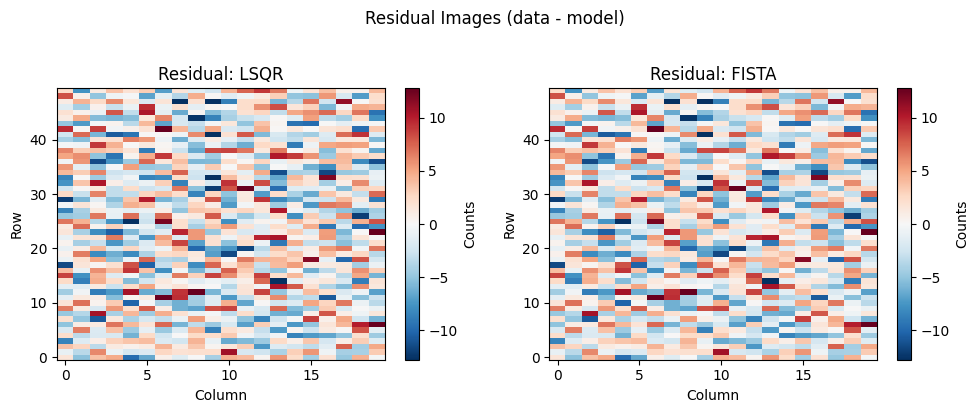

LSQR  residual RMS: 4.9436
FISTA residual RMS: 4.9436


In [8]:
# Reconstruct model images from recovered coefficients
f_model_lsqr  = scipy_op.apply(a_rec_scipy).reshape(IMAGE_SHAPE)
f_model_fista = jax_op.apply(a_rec_fista).reshape(IMAGE_SHAPE)

residual_lsqr  = f_noisy - f_model_lsqr
residual_fista = f_noisy - f_model_fista

vlim = np.percentile(np.abs(residual_lsqr), 99)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, resid, title in zip(
    axes,
    [residual_lsqr, residual_fista],
    ['Residual: LSQR', 'Residual: FISTA'],
):
    im = ax.imshow(resid, origin='lower', aspect='auto',
                   cmap='RdBu_r', vmin=-vlim, vmax=vlim)
    plt.colorbar(im, ax=ax, label='Counts')
    ax.set_title(title)
    ax.set_xlabel('Column')
    ax.set_ylabel('Row')
plt.suptitle('Residual Images (data - model)', y=1.02)
plt.tight_layout()
plt.show()
print(f'LSQR  residual RMS: {np.std(residual_lsqr):.4f}')
print(f'FISTA residual RMS: {np.std(residual_fista):.4f}')


### Per-Source RMSE Comparison

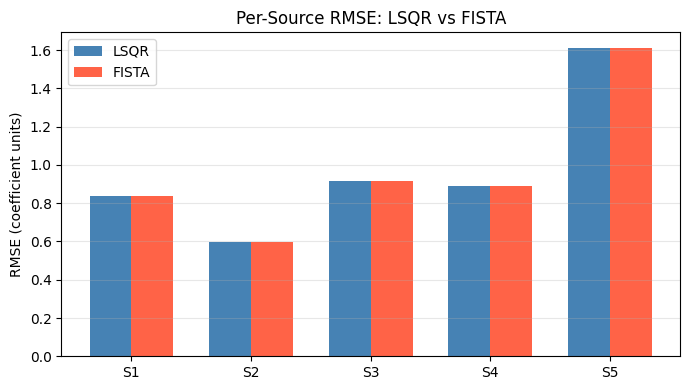

LSQR  RMSE per source: ['0.8388', '0.5973', '0.9136', '0.8911', '1.6121']
FISTA RMSE per source: ['0.8388', '0.5973', '0.9136', '0.8911', '1.6121']


In [9]:
rmse_lsqr  = [
    float(np.sqrt(np.mean(
        (a_rec_lsqr[k*M:(k+1)*M] - a_true_jax[k*M:(k+1)*M])**2
    )))
    for k in range(K)
]
rmse_fista = [
    float(np.sqrt(np.mean(
        (a_rec_fista[k*M:(k+1)*M] - a_true_jax[k*M:(k+1)*M])**2
    )))
    for k in range(K)
]

x = np.arange(K)
width = 0.35
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(x - width/2, rmse_lsqr,  width, label='LSQR',  color='steelblue')
ax.bar(x + width/2, rmse_fista, width, label='FISTA', color='tomato')
ax.set_xticks(x)
ax.set_xticklabels([f'S{k+1}' for k in range(K)])
ax.set_ylabel('RMSE (coefficient units)')
ax.set_title('Per-Source RMSE: LSQR vs FISTA')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()
print('LSQR  RMSE per source:', [f'{v:.4f}' for v in rmse_lsqr])
print('FISTA RMSE per source:', [f'{v:.4f}' for v in rmse_fista])


## Section 2: RMSE vs Source Density

<!-- HYPATIA: Introduce the sweep — what density means physically, -->
<!-- and why we care about the crossover point. -->

In [10]:
N_SOURCES_GRID = [1, 2, 3, 5, 8, 10, 15, 20]
N_TRIALS = 10
SWEEP_RNG = np.random.default_rng(2027)
REGULARISATION = 1e-2
LAM_FISTA = 0.05
print(f'Sweep grid: {N_SOURCES_GRID}, {N_TRIALS} trials each')


Sweep grid: [1, 2, 3, 5, 8, 10, 15, 20], 10 trials each


### Sweep Helper

In [11]:
def sweep_trial(
    config: InstrumentConfig,
    basis: EigenspectraBasis,
    image_shape: tuple,
    n_sources: int,
    rng: np.random.Generator,
    noise_model: NoiseModel,
) -> dict:
    """One Monte Carlo trial: build operators, solve, compute RMSE.

    Returns dict with keys 'rmse_lsqr' and 'rmse_fista'.
    """
    n_rows, n_cols = image_shape
    n_pix = n_rows * n_cols
    m = basis.n_components

    # Random source positions (row, col)
    flat_idx = rng.choice(n_pix, size=n_sources, replace=False)
    src_pos = np.column_stack([
        flat_idx // n_cols, flat_idx % n_cols
    ]).astype(np.float64)

    # Ground-truth coefficients
    a_true = rng.standard_normal(n_sources * m)

    # Build operators
    sp_op  = SciPySparseOperator.build(config, basis, image_shape)
    jx_op  = JAXOperator.build(config, basis, image_shape, src_pos)

    # Forward model + noise
    f_clean = jx_op.apply(a_true).reshape(image_shape)
    f_noisy_trial = noise_model.sample(f_clean, rng)

    # Support mask for SpectralSolver
    mask = np.zeros(n_pix * m, dtype=bool)
    for p in flat_idx:
        mask[p * m : (p + 1) * m] = True

    # LSQR
    a_lsqr_full = SpectralSolver(
        sp_op, noise_model=noise_model, regularisation=REGULARISATION
    ).solve(f_noisy_trial, support_mask=mask)
    a_lsqr = np.concatenate([
        a_lsqr_full[p * m : (p + 1) * m] for p in flat_idx
    ])

    # FISTA
    a_fista = JAXProximalSolver(
        jx_op, noise_model=noise_model, lam=LAM_FISTA, max_iter=200
    ).solve(f_noisy_trial)

    rmse_lsqr  = float(np.sqrt(np.mean((a_lsqr  - a_true)**2)))
    rmse_fista = float(np.sqrt(np.mean((a_fista - a_true)**2)))
    return {'rmse_lsqr': rmse_lsqr, 'rmse_fista': rmse_fista}

print('sweep_trial helper defined')


sweep_trial helper defined


### Run Sweep

In [12]:
sweep_results = {n: [] for n in N_SOURCES_GRID}

for n_src in N_SOURCES_GRID:
    for trial in range(N_TRIALS):
        trial_rng = np.random.default_rng(SWEEP_RNG.integers(0, 2**31))
        res = sweep_trial(
            config, basis, IMAGE_SHAPE, n_src, trial_rng, NOISE_MODEL
        )
        sweep_results[n_src].append(res)
    lsqr_m  = np.mean([r['rmse_lsqr']  for r in sweep_results[n_src]])
    fista_m = np.mean([r['rmse_fista'] for r in sweep_results[n_src]])
    print(f'n={n_src:2d}: LSQR {lsqr_m:.4f}  FISTA {fista_m:.4f}')


n= 1: LSQR 0.8776  FISTA 0.8776


n= 2: LSQR 0.9742  FISTA 0.9742


n= 3: LSQR 0.9222  FISTA 0.9222


n= 5: LSQR 1.0070  FISTA 1.0070


n= 8: LSQR 0.9689  FISTA 0.9689


n=10: LSQR 0.9993  FISTA 0.9993


n=15: LSQR 1.0336  FISTA 1.0336


n=20: LSQR 1.0027  FISTA 1.0027


### RMSE vs Source Density

<!-- HYPATIA: Interpret the crossover — at what density FISTA's group-L1 -->
<!-- regularisation clearly outperforms LSQR, and what this means for -->
<!-- observers targeting crowded NIRISS fields. -->

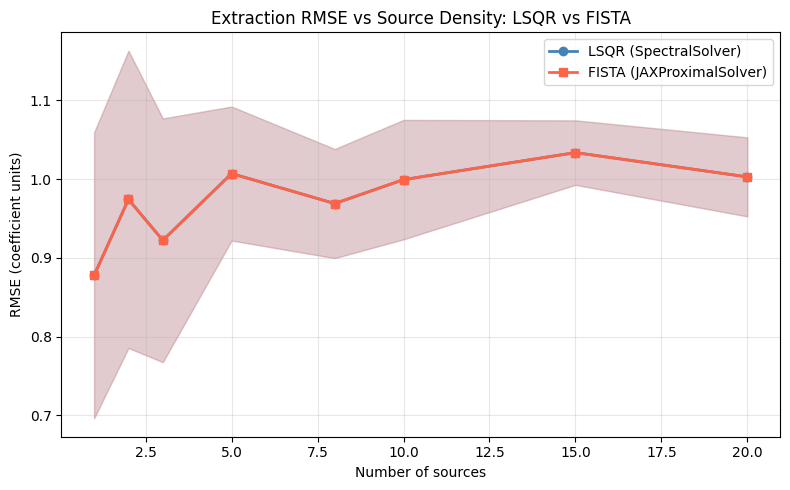

In [13]:
ns_arr = np.array(N_SOURCES_GRID)
lsqr_means  = np.array([np.mean([r['rmse_lsqr']  for r in sweep_results[n]]) for n in N_SOURCES_GRID])
lsqr_stds   = np.array([np.std( [r['rmse_lsqr']  for r in sweep_results[n]]) for n in N_SOURCES_GRID])
fista_means = np.array([np.mean([r['rmse_fista'] for r in sweep_results[n]]) for n in N_SOURCES_GRID])
fista_stds  = np.array([np.std( [r['rmse_fista'] for r in sweep_results[n]]) for n in N_SOURCES_GRID])

fig, ax = plt.subplots(figsize=(8, 5))
ax.fill_between(ns_arr, lsqr_means - lsqr_stds, lsqr_means + lsqr_stds,
                alpha=0.2, color='steelblue')
ax.fill_between(ns_arr, fista_means - fista_stds, fista_means + fista_stds,
                alpha=0.2, color='tomato')
ax.plot(ns_arr, lsqr_means,  'o-', color='steelblue', label='LSQR (SpectralSolver)', lw=2)
ax.plot(ns_arr, fista_means, 's-', color='tomato',    label='FISTA (JAXProximalSolver)', lw=2)
ax.set_xlabel('Number of sources')
ax.set_ylabel('RMSE (coefficient units)')
ax.set_title('Extraction RMSE vs Source Density: LSQR vs FISTA')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Summary

<!-- HYPATIA: Write a concise scientific summary — key findings, -->
<!-- recommendation for observers, and pointers to further work. -->
*Placeholder — see HYPATIA marker above.*